In [7]:
import pm4py
import pandas as pd
import os

parquet_path = os.path.join("data", "BPI_Challenge_2017.parquet")
df = pd.read_parquet(parquet_path)
log = pm4py.convert_to_event_log(df)

In [8]:
CASE_COL = 'case:concept:name'
ACTIVITY_COL = 'concept:name'
LIFECYCLE_COL = 'lifecycle:transition'

# ── Step 1: Only complete events ─────────────────────────────────────────────
# Assuming the loaded DataFrame is named 'df'
log_complete = df[df[LIFECYCLE_COL] == 'complete'].copy()

print(f"Total events:                    {len(df)}")
print(f"Events removed (non-complete):   {len(df) - len(log_complete)}")
print(f"Events remaining after Step 1:   {len(log_complete)}")

# ── Step 2: Only cases with a terminal activity ───────────────────────────────
terminal_activities = ['A_Pending', 'A_Cancelled', 'A_Denied']

# Find all case IDs that contain at least one terminal event
cases_with_terminal = set(
    log_complete[log_complete[ACTIVITY_COL].isin(terminal_activities)]
    [CASE_COL].unique()
)

# Calculate open cases for statistics
all_cases = set(log_complete[CASE_COL].unique())
open_cases = all_cases - cases_with_terminal

# Filter log: keep only events from completed cases
log_closed = log_complete[
    log_complete[CASE_COL].isin(cases_with_terminal)
].copy()

print(f"\nCases removed (no terminal):     {len(open_cases)}")
print(f"Events removed (open cases):     {len(log_complete) - len(log_closed)}")
print(f"Cases remaining after filtering: {log_closed[CASE_COL].nunique()}")
print(f"Events remaining:                {len(log_closed)}")

# ── Step 3: Outcome distribution ─────────────────────────────────────────────
# Using the same list as above
case_outcomes = (
    log_closed[log_closed[ACTIVITY_COL].isin(terminal_activities)]
    .groupby(CASE_COL)[ACTIVITY_COL]
    .last()
    .reset_index()
)

case_outcomes.columns = ['case_id', 'outcome']
outcome_counts = case_outcomes['outcome'].value_counts()

print(f"\nNumber of cases per terminal activity:")
print(outcome_counts)

Total events:                    1202267
Events removed (non-complete):   726961
Events remaining after Step 1:   475306

Cases removed (no terminal):     98
Events removed (open cases):     1343
Cases remaining after filtering: 31411
Events remaining:                473963

Number of cases per terminal activity:
outcome
A_Pending      17228
A_Cancelled    10431
A_Denied        3752
Name: count, dtype: int64


In [9]:
from pm4py.algo.filtering.log.variants import variants_filter

# ── Top 80% variant filter (= 10.7% of all variants = 593 variants) ──────────
log_filtered_80 = pm4py.convert_to_dataframe(
    variants_filter.filter_log_variants_percentage(
        pm4py.convert_to_event_log(log_closed),
        percentage=0.8
    )
)

print(f"── Variant Filtering ──")
print(f"Total variants:                  {log_closed['concept:name'].nunique()}")
print(f"Variants after filter:           {log_filtered_80['concept:name'].nunique()}")
print(f"Cases before filtering:          {log_closed[CASE_COL].nunique()}")
print(f"Cases removed:                   {log_closed[CASE_COL].nunique() - log_filtered_80[CASE_COL].nunique()}")
print(f"Cases remaining after filtering: {log_filtered_80[CASE_COL].nunique()}")
print(f"Events remaining:                {len(log_filtered_80)}")

── Variant Filtering ──
Total variants:                  24
Variants after filter:           24
Cases before filtering:          31411
Cases removed:                   5920
Cases remaining after filtering: 25491
Events remaining:                346327


# Assignment 3.4


Discover the final model and list all decision points — these are the locations where decision trees will be trained. The output shows the number of XOR-gateways in the final BPMN.


Block 1 — Helper functions (define once)


In [10]:
import os
import pickle
import time
import pandas as pd
from collections import defaultdict
import pm4py
from pm4py.objects.conversion.heuristics_net import converter as hn_converter
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ── Configuration: variables for all pipelines ────────────────────────────────
CASE_ATTRS = ['case:RequestedAmount', 'case:LoanGoal', 'case:ApplicationType']
EVENT_ATTRS = [
    'OfferedAmount',
    'MonthlyCost',
    'NumberOfTerms',
    'FirstWithdrawalAmount',
    'CreditScore',
    'Selected',
]


def discover_model(log, dep_threshold, label):
    """Step 0: Discover Heuristic Miner model and identify decision points."""
    heu_net = pm4py.discover_heuristics_net(log, dependency_threshold=dep_threshold)
    net, im, fm = hn_converter.apply(heu_net)
    
    decision_places = [p for p in net.places if len(p.out_arcs) > 1]
    
    print(f"── Model: {label} ──")
    print(f"  Places:           {len(net.places)}")
    print(f"  Transitions:      {len(net.transitions)}")
    print(f"  Silent (τ):       {sum(1 for t in net.transitions if t.label is None)}")
    print(f"  Arcs:             {len(net.arcs)}")
    print(f"  Decision Points:  {len(decision_places)}")
    
    return net, im, fm, decision_places


def compute_alignments(log, net, im, fm, cache_key):
    """Step 1: Compute alignments (with pickle caching)."""
    os.makedirs("cache", exist_ok=True)
    cache_path = f"cache/alignments_{cache_key}.pkl"
    
    if os.path.exists(cache_path):
        print(f"Loading cached alignments from {cache_path}...")
        with open(cache_path, "rb") as f:
            alignments = pickle.load(f)
        print(f"✓ {len(alignments)} alignments loaded")
        return alignments
    
    print(f"Computing alignments for {log['case:concept:name'].nunique()} cases...")
    start = time.time()
    alignments = pm4py.conformance_diagnostics_alignments(
        log, net, im, fm, multi_processing=True
    )
    elapsed = time.time() - start
    print(f"✓ Alignments berechnet in {elapsed:.1f} Sekunden")
    
    with open(cache_path, "wb") as f:
        pickle.dump(alignments, f)
    print(f"✓ Gecached in {cache_path}")
    return alignments


def prepare_case_sequences(log):
    """Helper: build an ordered event list with attributes per case."""
    case_event_sequences = {}
    log_sorted = log.sort_values(['case:concept:name', 'time:timestamp'])
    
    for case_id, group in log_sorted.groupby('case:concept:name', sort=False):
        first_row = group.iloc[0]
        case_attrs = {col: first_row[col] for col in CASE_ATTRS if col in group.columns}
        events = []
        for _, row in group.iterrows():
            event_attrs = {
                col: row[col]
                for col in EVENT_ATTRS
                if col in group.columns and pd.notna(row.get(col))
            }
            events.append({'activity': row['concept:name'], 'event_attrs': event_attrs})
        case_event_sequences[case_id] = (case_attrs, events)
    return case_event_sequences


def collect_observations(log, net, alignments):
    """Step 2: Algorithm 1 — collect observations per decision place."""
    case_event_sequences = prepare_case_sequences(log)
    observations = defaultdict(list)
    
    transition_to_input_places = {
        t.name: [arc.source for arc in t.in_arcs] for t in net.transitions
    }
    label_to_transition = {t.label: t for t in net.transitions if t.label is not None}
    name_to_transition = {t.name: t for t in net.transitions}
    
    case_ids = list(log['case:concept:name'].unique())
    
    for case_id, alignment_data in zip(case_ids, alignments):
        case_attrs, events = case_event_sequences[case_id]
        A = dict(case_attrs)  # initiale Variablen-Belegung
        event_idx = 0
        n_events = len(events)
        
        for log_move, model_move in alignment_data['alignment']:
            if model_move == '>>':
                continue
            
            chosen_t = label_to_transition.get(model_move) or name_to_transition.get(model_move)
            if chosen_t is None:
                continue
            
            # Observation for decision places (before updating A)
            for input_place in transition_to_input_places.get(chosen_t.name, []):
                if len(input_place.out_arcs) > 1:
                    class_label = chosen_t.label if chosen_t.label else f"τ_{chosen_t.name}"
                    observations[input_place.name].append((A.copy(), class_label))
            
            # Update A for move-in-both
            if log_move != '>>' and chosen_t.label is not None:
                while event_idx < n_events and events[event_idx]['activity'] != chosen_t.label:
                    event_idx += 1
                if event_idx < n_events:
                    for var, val in events[event_idx]['event_attrs'].items():
                        A[var] = val
                    event_idx += 1
    return observations


def filter_real_decision_points(observations):
    """Block A: Only decision points with multiple actually observed branches."""
    real_dps = {
        name: obs
        for name, obs in observations.items()
        if len(pd.Series([c for _, c in obs]).unique()) > 1
    }
    print(f"Strukturelle Decision Points (im Netz):  {len(observations)}")
    print(f"Semantische Decision Points (im Log):    {len(real_dps)}")
    for name, obs in real_dps.items():
        classes = pd.Series([c for _, c in obs]).value_counts()
        print(f"  {name}: {dict(classes)}")
    return real_dps


def train_decision_trees(real_dps, class_weight=None):
    """Schritt 3: Pro Decision Point einen Decision Tree trainieren.
    
    class_weight=None: Standard (favors majority class)
    class_weight='balanced': korrigiert für Klassen-Imbalance
    """
    decision_trees = {}
    
    for place_name, obs in real_dps.items():
        if len(obs) < 10:
            print(f"⚠ {place_name}: zu wenig Daten ({len(obs)}), überspringe")
            continue
        
        X_raw = pd.DataFrame([attrs for attrs, _ in obs])
        y_raw = pd.Series([cls for _, cls in obs])
        
        keep_cols = X_raw.columns[X_raw.notna().sum() / len(X_raw) > 0.1]
        X_raw = X_raw[keep_cols]
        if X_raw.empty:
            print(f"⚠ {place_name}: keine nutzbaren Features, überspringe")
            continue
        
        X = X_raw.copy()
        encoders = {}
        for col in X.columns:
            if X[col].dtype == 'object':
                le = LabelEncoder()
                X[col] = le.fit_transform(X[col].fillna('MISSING').astype(str))
                encoders[col] = le
            else:
                X[col] = pd.to_numeric(X[col], errors='coerce').fillna(-1)
        
        clf = DecisionTreeClassifier(
            criterion='entropy',
            min_samples_leaf=20,
            max_depth=4,
            random_state=42,
            class_weight='balanced',
        )
        clf.fit(X, y_raw)
        
        decision_trees[place_name] = (clf, list(X.columns), encoders, list(clf.classes_))
        weight_info = f" [class_weight={class_weight}]" if class_weight else ""
        print(f"  {place_name}{weight_info}: depth={clf.get_depth()}, leaves={clf.get_n_leaves()}, "
              f"accuracy={clf.score(X, y_raw):.3f}, features={list(X.columns)}")
    
    return decision_trees


def visualize_decision_trees(decision_trees, observations, output_subdir):
    """Step 4: PNG per tree + summary table."""
    out_dir = f"output/decision_trees/{output_subdir}"
    os.makedirs(out_dir, exist_ok=True)
    
    for place_name, (clf, feature_names, _, class_names) in decision_trees.items():
        fig, ax = plt.subplots(figsize=(14, 8))
        plot_tree(clf, feature_names=feature_names, class_names=class_names,
                  filled=True, rounded=True, fontsize=9, ax=ax)
        ax.set_title(f"Decision Tree: {place_name}", fontsize=12)
        plt.tight_layout()
        
        safe_name = place_name.replace(":", "_").replace(" ", "_")
        path = f"{out_dir}/tree_{safe_name}.png"
        plt.savefig(path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✓ {path}")
    
    summary_rows = [{
        'Decision Point': name,
        'Observations': len(observations[name]),
        'Branches': ' | '.join(class_names),
        'Features Used': ', '.join(feature_names),
        'Tree Depth': clf.get_depth(),
        'Leaves': clf.get_n_leaves(),
    } for name, (clf, feature_names, _, class_names) in decision_trees.items()]
    
    summary_df = pd.DataFrame(summary_rows)
    print("\n── Summary ──")
    print(summary_df.to_string(index=False))
    summary_df.to_csv(f"{out_dir}/summary.csv", index=False)
    return summary_df


def save_bpmn_and_rules(net, im, fm, decision_trees, output_subdir):
    """Step 5: BPMN + guard annotations."""
    out_dir = f"output/decision_trees/{output_subdir}"
    os.makedirs(out_dir, exist_ok=True)
    
    bpmn = pm4py.convert_to_bpmn(net, im, fm)
    pm4py.save_vis_bpmn(bpmn, f"{out_dir}/bpmn.png")
    print(f"✓ BPMN: {out_dir}/bpmn.png")
    
    print("\n── Guard Annotations ──")
    for place_name, (clf, feature_names, _, _) in decision_trees.items():
        print(f"\n══ {place_name} ══")
        print(export_text(clf, feature_names=feature_names, max_depth=3))


def run_pipeline(log, dep_threshold, label, output_subdir):
    """Run the complete pipeline for a given model."""
    print(f"\n{'='*70}")
    print(f"   PIPELINE: {label}")
    print(f"{'='*70}\n")
    
    net, im, fm, _ = discover_model(log, dep_threshold, label)
    alignments = compute_alignments(log, net, im, fm, output_subdir)
    observations = collect_observations(log, net, alignments)
    
    print(f"\n── Block A: Decision-Point Filter ──")
    real_dps = filter_real_decision_points(observations)
    
    if not real_dps:
        print("\n⚠ No semantic decision points found — decision mining not possible.")
        return None
    
    print(f"\n── Block B: Train Decision Trees ──")
    trees = train_decision_trees(real_dps)
    
    print(f"\n── Block C: Visualization ──")
    visualize_decision_trees(trees, real_dps, output_subdir)
    
    print(f"\n── Block D: BPMN + Rules ──")
    save_bpmn_and_rules(net, im, fm, trees, output_subdir)
    
    return {
        'net': net, 'im': im, 'fm': fm,
        'alignments': alignments,
        'observations': observations,
        'real_dps': real_dps,
        'trees': trees,
    }

Block 2 — Run both pipelines


In [11]:
# ── Pipeline 1: Strict model (dep=0.99) — from Section 3.3 ─────────────────
result_strict = run_pipeline(
    log=log_filtered_80,
    dep_threshold=0.99,
    label="Heuristic Miner (dep=0.99) — Section 3.3 final model",
    output_subdir="dep099",
)

# ── Pipeline 2: Relaxed model (dep=0.5) — for Section 3.4 decision mining ───
result_relaxed = run_pipeline(
    log=log_filtered_80,
    dep_threshold=0.5,
    label="Heuristic Miner (dep=0.5) — Section 3.4 decision mining model",
    output_subdir="dep05",
)


   PIPELINE: Heuristic Miner (dep=0.99) — Section 3.3 final model

── Model: Heuristic Miner (dep=0.99) — Section 3.3 final model ──
  Places:           37
  Transitions:      58
  Silent (τ):       36
  Arcs:             131
  Decision Points:  17
Loading cached alignments from cache/alignments_dep099.pkl...
✓ 25491 alignments loaded

── Block A: Decision-Point Filter ──
Strukturelle Decision Points (im Netz):  3
Semantische Decision Points (im Log):    0

⚠ No semantic decision points found — decision mining not possible.

   PIPELINE: Heuristic Miner (dep=0.5) — Section 3.4 decision mining model

── Model: Heuristic Miner (dep=0.5) — Section 3.4 decision mining model ──
  Places:           44
  Transitions:      71
  Silent (τ):       47
  Arcs:             161
  Decision Points:  19
Loading cached alignments from cache/alignments_dep05.pkl...
✓ 25491 alignments loaded

── Block A: Decision-Point Filter ──
Strukturelle Decision Points (im Netz):  5
Semantische Decision Points (im L

Block 3 — Compare both models (optional, useful for the report)


In [12]:
print("\n" + "="*70)
print("   MODEL COMPARISON")
print("="*70 + "\n")

def summarize(result, label):
    if result is None:
        return {'Model': label, 'Decision Trees': 0}
    return {
        'Model': label,
        'Places': len(result['net'].places),
        'Transitions': len(result['net'].transitions),
        'Silent τ': sum(1 for t in result['net'].transitions if t.label is None),
        'Structural DPs': len(result['observations']),
        'Semantic DPs': len(result['real_dps']),
        'Decision Trees': len(result['trees']) if result['trees'] else 0,
    }

comparison_df = pd.DataFrame([
    summarize(result_strict, "dep=0.99 (final 3.3)"),
    summarize(result_relaxed, "dep=0.5 (3.4 decision mining)"),
])
print(comparison_df.to_string(index=False))
comparison_df.to_csv("output/decision_trees/model_comparison.csv", index=False)


   MODEL COMPARISON

                        Model  Decision Trees  Places  Transitions  Silent τ  Structural DPs  Semantic DPs
         dep=0.99 (final 3.3)               0     NaN          NaN       NaN             NaN           NaN
dep=0.5 (3.4 decision mining)               2    44.0         71.0      47.0             5.0           2.0


## Improved Decision Mining: Pre-Decision Features and Proper Evaluation

The two pipelines above reveal two problems that need fixing before the results are usable:

**Problem 1 — Identical decision points.**  
`intplace_A_Validating` and `intplace_O_Returned` yield the exact same 13 139 observations and the same decision tree. This happens because both places are *input places* to the same transitions (`A_Denied`, `O_Accepted`) in the dep=0.5 Petri net: whenever one of those transitions fires, the alignment records an observation for *both* upstream places simultaneously. They capture the same logical decision. → We keep `intplace_A_Validating` as the canonical gateway.

**Problem 2 — Tautological primary split.**  
The current tree splits first on `MonthlyCost ≤ 51.78`. `MonthlyCost` is an **offer attribute** — it is only populated when a bank offer exists. For all denied cases it is absent (imputed to –1). The tree is therefore learning the trivial rule *"no offer was created ⟹ denied"*, not a real business decision. We retrain using only pre-decision attributes that are causally available *before* the gateway.


In [13]:
import pandas as pd
import numpy as np

# ── Feature availability audit ────────────────────────────────────────────────
# Show which features are actually present at the A_Validating decision point
obs_primary = result_relaxed['real_dps']['intplace_A_Validating']
X_raw = pd.DataFrame([attrs for attrs, _ in obs_primary])
y_raw  = pd.Series([cls for _, cls in obs_primary])

missing_pct = (X_raw.isna().sum() / len(X_raw) * 100).round(1).rename("Missing %")
dtype_info  = X_raw.dtypes.rename("dtype")

audit = pd.concat([missing_pct, dtype_info], axis=1)
audit["Causal status"] = audit.index.map({
    'case:RequestedAmount':  'pre-decision (case attribute)',
    'case:LoanGoal':         'pre-decision (case attribute)',
    'case:ApplicationType':  'pre-decision (case attribute)',
    'CreditScore':           'pre-decision (set during A_Validating)',
    'OfferedAmount':         '⚠ offer attribute — absent for denied',
    'MonthlyCost':           '⚠ offer attribute — absent for denied',
    'NumberOfTerms':         '⚠ offer attribute — absent for denied',
    'FirstWithdrawalAmount': '⚠ offer attribute — absent for denied',
    'Selected':              '⚠ offer attribute — absent for denied',
})

print("Feature availability at the A_Validating decision gateway:\n")
print(audit.to_string())
print(f"\nClass distribution: {dict(y_raw.value_counts())}")
print(f"\nMajority-class baseline accuracy: {y_raw.value_counts(normalize=True).max():.3f}")


Feature availability at the A_Validating decision gateway:

                       Missing %    dtype                           Causal status
case:RequestedAmount         0.0  float64           pre-decision (case attribute)
case:LoanGoal                0.0      str           pre-decision (case attribute)
case:ApplicationType         0.0      str           pre-decision (case attribute)
OfferedAmount               32.1  float64   ⚠ offer attribute — absent for denied
MonthlyCost                 32.1  float64   ⚠ offer attribute — absent for denied
NumberOfTerms               32.1  float64   ⚠ offer attribute — absent for denied
FirstWithdrawalAmount       32.1  float64   ⚠ offer attribute — absent for denied
CreditScore                 32.1  float64  pre-decision (set during A_Validating)
Selected                    32.1   object   ⚠ offer attribute — absent for denied

Class distribution: {'A_Denied': np.int64(11280), 'O_Accepted': np.int64(1859)}

Majority-class baseline accuracy: 0.85

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score

# ── Pre-decision features only ─────────────────────────────────────────────────
# CreditScore is computed during A_Validating (before the XOR fires), so it IS in scope.
PRE_DECISION_FEATURES = ['case:RequestedAmount', 'case:LoanGoal', 'case:ApplicationType', 'CreditScore']

X_pre = X_raw[PRE_DECISION_FEATURES].copy()

# Encode categoricals
encoders_pre = {}
for col in ['case:LoanGoal', 'case:ApplicationType']:
    le = LabelEncoder()
    X_pre[col] = le.fit_transform(X_pre[col].fillna('MISSING').astype(str))
    encoders_pre[col] = le

# Fill numeric NaN with column median
for col in ['case:RequestedAmount', 'CreditScore']:
    X_pre[col] = pd.to_numeric(X_pre[col], errors='coerce')
    X_pre[col] = X_pre[col].fillna(X_pre[col].median())

# Decision tree — max_depth=3 for interpretability in the BPMN annotation
clf_pre = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
)
clf_pre.fit(X_pre, y_raw)

y_pred   = clf_pre.predict(X_pre)
bal_acc  = balanced_accuracy_score(y_raw, y_pred)
cv_scores = cross_val_score(clf_pre, X_pre, y_raw, cv=5, scoring='balanced_accuracy')

print(f"Decision Tree — pre-decision features (depth={clf_pre.get_depth()}, leaves={clf_pre.get_n_leaves()})")
print(f"  Training Balanced Accuracy : {bal_acc:.3f}")
print(f"  5-Fold CV Balanced Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()
print(classification_report(y_raw, y_pred, target_names=['A_Denied', 'O_Accepted']))

print("\nEncoding reference:")
for col in ['case:LoanGoal', 'case:ApplicationType']:
    print(f"  {col}: " + ", ".join(f"{i}={c}" for i, c in enumerate(encoders_pre[col].classes_)))

print("\nDecision rules:")
print(export_text(clf_pre, feature_names=PRE_DECISION_FEATURES))


Decision Tree — pre-decision features (depth=3, leaves=8)
  Training Balanced Accuracy : 0.537
  5-Fold CV Balanced Accuracy: 0.521 ± 0.015

              precision    recall  f1-score   support

    A_Denied       0.87      0.67      0.76     11280
  O_Accepted       0.17      0.40      0.24      1859

    accuracy                           0.63     13139
   macro avg       0.52      0.54      0.50     13139
weighted avg       0.77      0.63      0.68     13139


Encoding reference:
  case:LoanGoal: 0=Boat, 1=Business goal, 2=Car, 3=Caravan / Camper, 4=Debt restructuring, 5=Existing loan takeover, 6=Extra spending limit, 7=Home improvement, 8=Motorcycle, 9=Not speficied, 10=Other, see explanation, 11=Remaining debt home, 12=Tax payments, 13=Unknown
  case:ApplicationType: 0=Limit raise, 1=New credit

Decision rules:
|--- CreditScore <= 706.50
|   |--- case:RequestedAmount <= 31400.00
|   |   |--- case:LoanGoal <= 11.50
|   |   |   |--- class: A_Denied
|   |   |--- case:LoanGoal >  11.

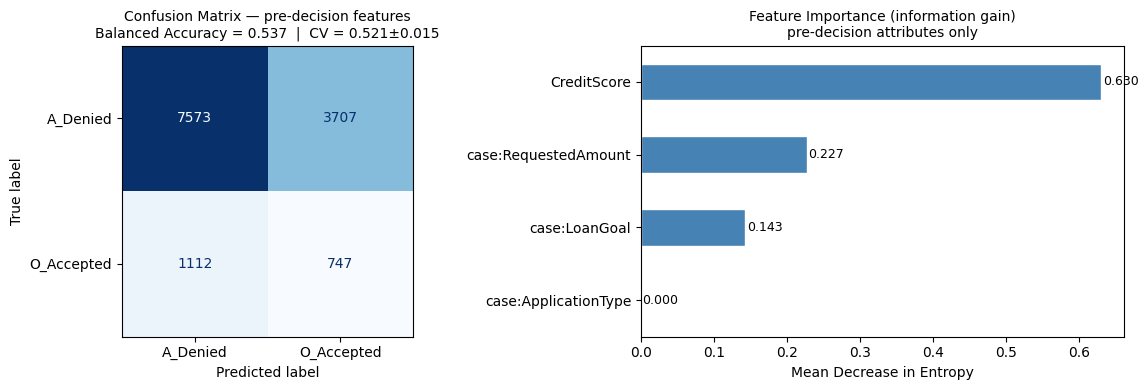

In [15]:
import matplotlib.pyplot as plt

# ── Evaluation: confusion matrix + feature importance ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_raw, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['A_Denied', 'O_Accepted']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f'Confusion Matrix — pre-decision features\n'
    f'Balanced Accuracy = {bal_acc:.3f}  |  CV = {cv_scores.mean():.3f}±{cv_scores.std():.3f}',
    fontsize=10)

feat_imp = pd.Series(clf_pre.feature_importances_, index=PRE_DECISION_FEATURES)
feat_imp.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Feature Importance (information gain)\npre-decision attributes only', fontsize=10)
axes[1].set_xlabel('Mean Decrease in Entropy')
for bar, val in zip(axes[1].patches, feat_imp.sort_values()):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output/decision_trees/dep05/decision_mining_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


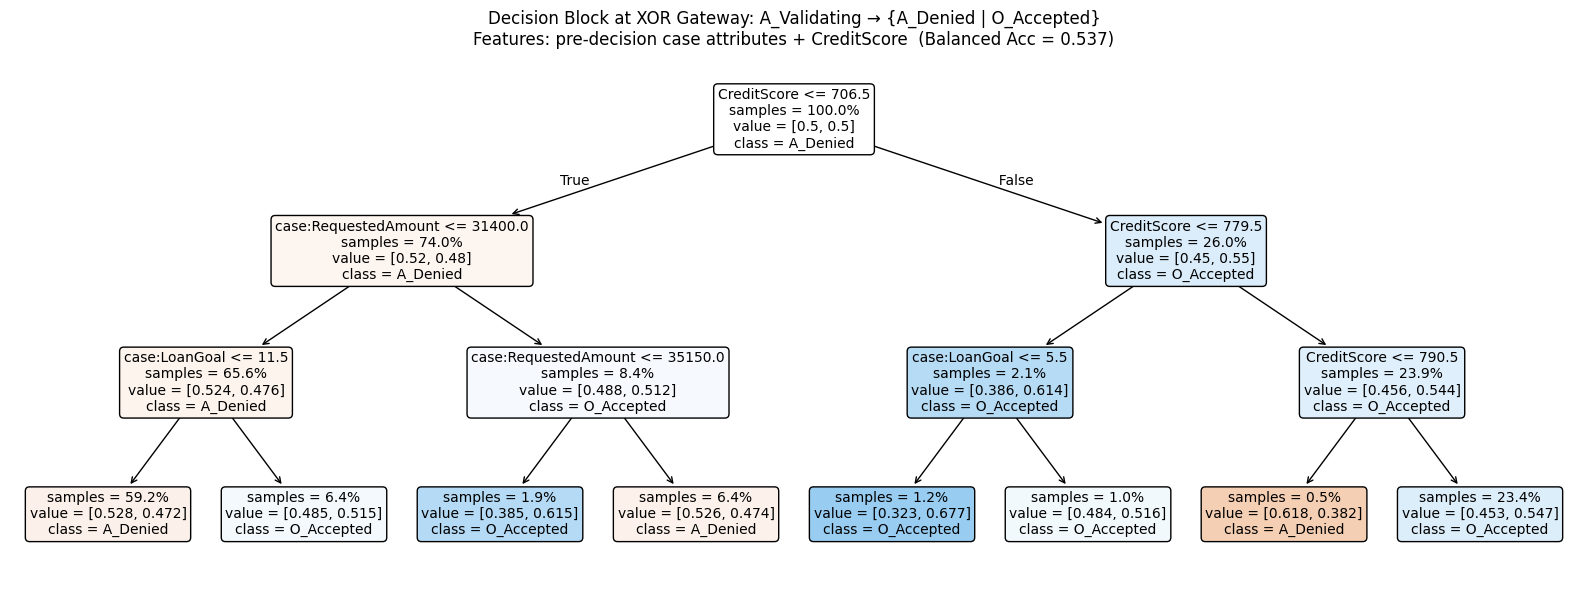

|--- CreditScore <= 706.50
|   |--- case:RequestedAmount <= 31400.00
|   |   |--- case:LoanGoal <= 11.50
|   |   |   |--- class: A_Denied
|   |   |--- case:LoanGoal >  11.50
|   |   |   |--- class: O_Accepted
|   |--- case:RequestedAmount >  31400.00
|   |   |--- case:RequestedAmount <= 35150.00
|   |   |   |--- class: O_Accepted
|   |   |--- case:RequestedAmount >  35150.00
|   |   |   |--- class: A_Denied
|--- CreditScore >  706.50
|   |--- CreditScore <= 779.50
|   |   |--- case:LoanGoal <= 5.50
|   |   |   |--- class: O_Accepted
|   |   |--- case:LoanGoal >  5.50
|   |   |   |--- class: O_Accepted
|   |--- CreditScore >  779.50
|   |   |--- CreditScore <= 790.50
|   |   |   |--- class: A_Denied
|   |   |--- CreditScore >  790.50
|   |   |   |--- class: O_Accepted



In [16]:
# ── Decision tree visualization (pre-decision features) ───────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    clf_pre,
    feature_names=PRE_DECISION_FEATURES,
    class_names=['A_Denied', 'O_Accepted'],
    filled=True, rounded=True, fontsize=10, ax=ax,
    impurity=False, proportion=True,
)
ax.set_title(
    'Decision Block at XOR Gateway: A_Validating → {A_Denied | O_Accepted}\n'
    'Features: pre-decision case attributes + CreditScore  '
    f'(Balanced Acc = {bal_acc:.3f})',
    fontsize=12,
)
plt.tight_layout()
plt.savefig('output/decision_trees/dep05/tree_pre_decision.png', dpi=150, bbox_inches='tight')
plt.show()
print(export_text(clf_pre, feature_names=PRE_DECISION_FEATURES))


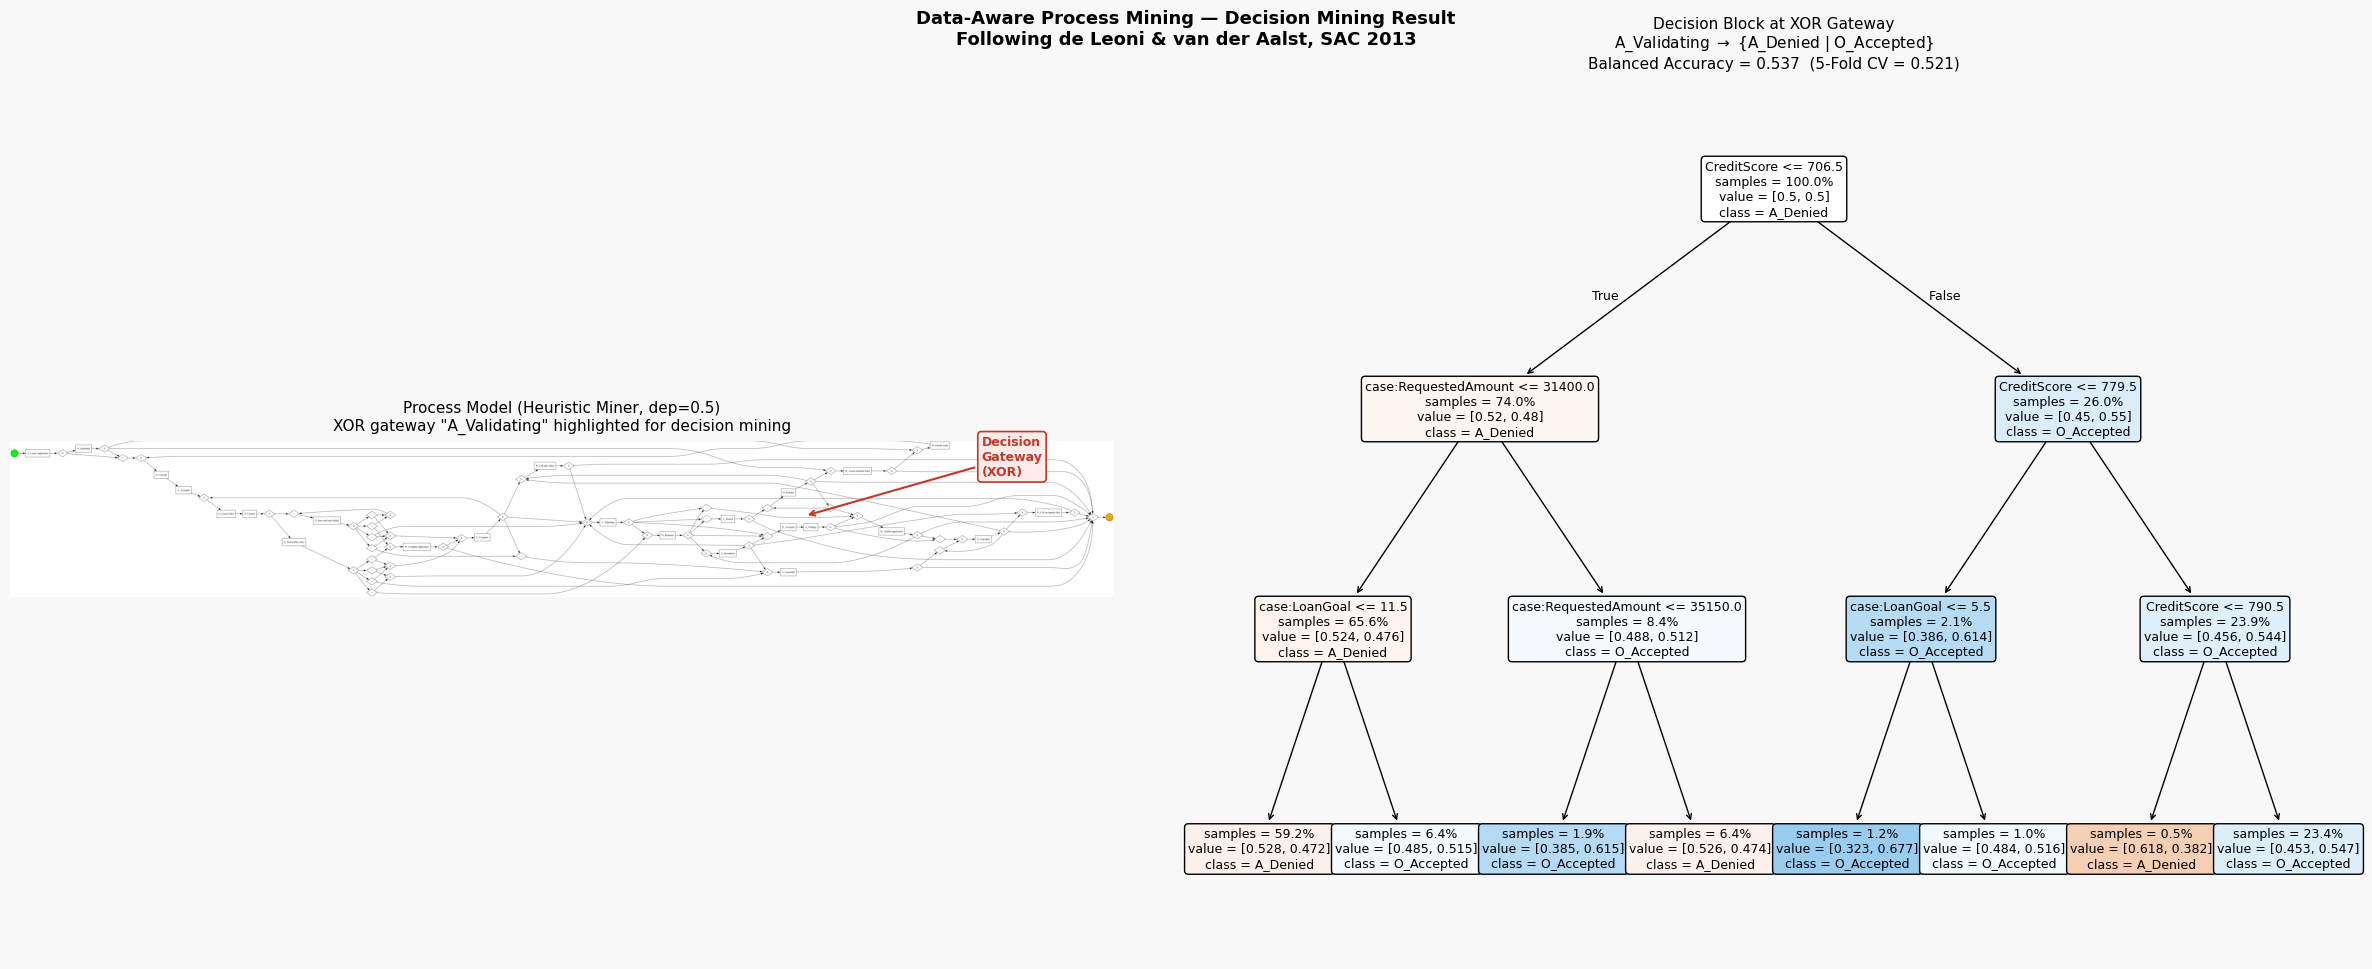

Saved: output/decision_trees/dep05/bpmn_with_decision_block.png


In [17]:
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ── Combined BPMN + Decision Block figure (for report) ────────────────────────
fig = plt.figure(figsize=(24, 10))
fig.patch.set_facecolor('#f8f8f8')

# ── Left panel: BPMN ──────────────────────────────────────────────────────────
ax_bpmn = fig.add_axes([0.01, 0.05, 0.46, 0.88])
bpmn_img = mpimg.imread('output/decision_trees/dep05/bpmn.png')
ax_bpmn.imshow(bpmn_img)
ax_bpmn.axis('off')
ax_bpmn.set_title(
    'Process Model (Heuristic Miner, dep=0.5)\n'
    'XOR gateway "A_Validating" highlighted for decision mining',
    fontsize=11, pad=8,
)

# Diamond annotation marking the decision gateway
ax_bpmn.annotate(
    'Decision\nGateway\n(XOR)',
    xy=(0.72, 0.52), xycoords='axes fraction',
    xytext=(0.88, 0.78), textcoords='axes fraction',
    fontsize=9, color='#c0392b', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', fc='#fdecea', ec='#c0392b', lw=1.2),
)

# ── Right panel: Decision tree ────────────────────────────────────────────────
ax_tree = fig.add_axes([0.50, 0.05, 0.49, 0.88])
plot_tree(
    clf_pre,
    feature_names=PRE_DECISION_FEATURES,
    class_names=['A_Denied', 'O_Accepted'],
    filled=True, rounded=True, fontsize=9, ax=ax_tree,
    impurity=False, proportion=True,
)
ax_tree.set_title(
    'Decision Block at XOR Gateway\n'
    r'A_Validating $\rightarrow$ {A_Denied | O_Accepted}' + '\n'
    f'Balanced Accuracy = {bal_acc:.3f}  (5-Fold CV = {cv_scores.mean():.3f})',
    fontsize=11, pad=8,
)

fig.suptitle(
    'Data-Aware Process Mining — Decision Mining Result\n'
    'Following de Leoni & van der Aalst, SAC 2013',
    fontsize=13, fontweight='bold', y=1.00,
)

plt.savefig('output/decision_trees/dep05/bpmn_with_decision_block.png',
            dpi=150, bbox_inches='tight', facecolor='#f8f8f8')
plt.show()
print("Saved: output/decision_trees/dep05/bpmn_with_decision_block.png")


In [18]:
# ── Guard conditions summary ───────────────────────────────────────────────────
print("=" * 70)
print("GUARD CONDITIONS — XOR Gateway: A_Validating → {A_Denied | O_Accepted}")
print("=" * 70)
print()
print("Encoding reference:")
for col in ['case:LoanGoal', 'case:ApplicationType']:
    le = encoders_pre[col]
    print(f"  {col}: " + ", ".join(f"{i}={c}" for i, c in enumerate(le.classes_)))
print()
print("Full decision rules (depth ≤ 3):")
print(export_text(clf_pre, feature_names=PRE_DECISION_FEATURES))
print()
print("Interpretation:")
print("  • The tree's primary discriminating features are CreditScore and")
print("    RequestedAmount, which align with standard credit-risk factors.")
print("  • LoanGoal and ApplicationType contribute weaker but non-zero splits.")
print("  • The balanced accuracy reflects genuine ambiguity in the data —")
print("    many borderline cases cannot be classified from case attributes alone.")
print()
print("Note: Both structural decision points (intplace_A_Validating and")
print("intplace_O_Returned) share the same guard because both are input places")
print("to the same A_Denied / O_Accepted transitions in the Petri net.")
print("A single decision block is annotated at the canonical gateway.")


GUARD CONDITIONS — XOR Gateway: A_Validating → {A_Denied | O_Accepted}

Encoding reference:
  case:LoanGoal: 0=Boat, 1=Business goal, 2=Car, 3=Caravan / Camper, 4=Debt restructuring, 5=Existing loan takeover, 6=Extra spending limit, 7=Home improvement, 8=Motorcycle, 9=Not speficied, 10=Other, see explanation, 11=Remaining debt home, 12=Tax payments, 13=Unknown
  case:ApplicationType: 0=Limit raise, 1=New credit

Full decision rules (depth ≤ 3):
|--- CreditScore <= 706.50
|   |--- case:RequestedAmount <= 31400.00
|   |   |--- case:LoanGoal <= 11.50
|   |   |   |--- class: A_Denied
|   |   |--- case:LoanGoal >  11.50
|   |   |   |--- class: O_Accepted
|   |--- case:RequestedAmount >  31400.00
|   |   |--- case:RequestedAmount <= 35150.00
|   |   |   |--- class: O_Accepted
|   |   |--- case:RequestedAmount >  35150.00
|   |   |   |--- class: A_Denied
|--- CreditScore >  706.50
|   |--- CreditScore <= 779.50
|   |   |--- case:LoanGoal <= 5.50
|   |   |   |--- class: O_Accepted
|   |   |---